In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


iris = sns.load_dataset('iris')
iris.sample(6)

,sepal_length,sepal_width,petal_length,petal_width,species
124,6.7,3.3,5.7,2.1,virginica
79,5.7,2.6,3.5,1.0,versicolor
77,6.7,3.0,5.0,1.7,versicolor
1,4.9,3.0,1.4,0.2,setosa
138,6.0,3.0,4.8,1.8,virginica
59,5.2,2.7,3.9,1.4,versicolor


# Seaborn

- https://seaborn.pydata.org/tutorial.html
  
- https://seaborn.pydata.org/examples/index.html

- Intérêt :
    1. Éviter de faire des boucles for pour ajouter des couches si on a déjà un pd.DataFrame
    2. Avoir accès à des graphiques  pour des statistiques plus avancés



In [2]:
import seaborn as sns

## graphiques similaires à plt
### barplot

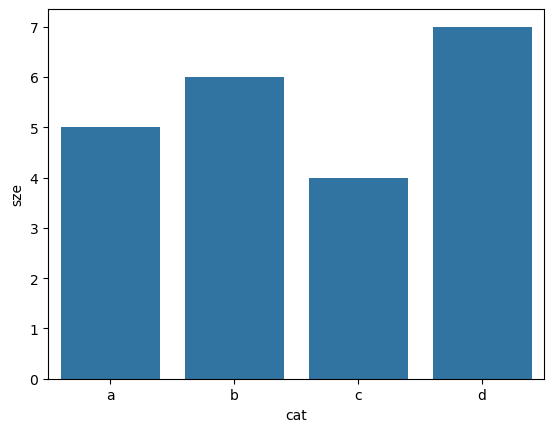

In [3]:
### creation data
GB = pd.DataFrame({"cat":list('abcd'),"sze":np.random.randint(2,8,4)})

## simple barplot disponible, comme dans matplotlib
sns.barplot(data = GB, x = "cat", y="sze")
## les "xlabel" et "ylabel" déjà inclu dans le graphique

plt.show() ## seaborn utilse du matplotlib en arrière-plan

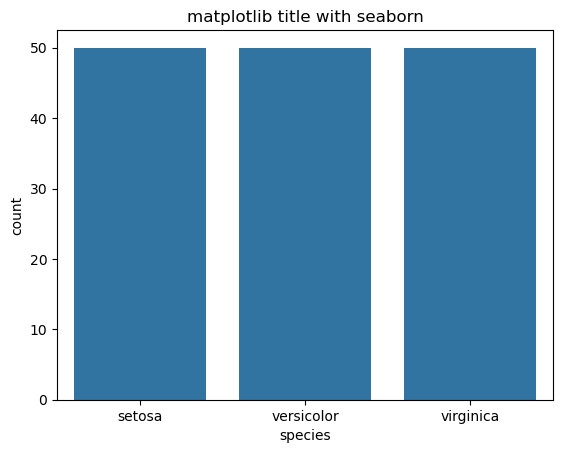

In [4]:
# countplot = barplot + count
sns.countplot(data = iris , x = 'species') ## pas besoin de faire un groupby pour obtenir le graphique
plt.title("matplotlib title with seaborn")
plt.show()

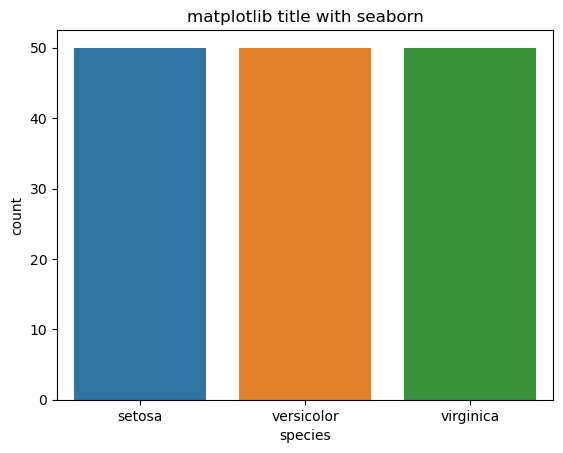

In [5]:
## pas besoin d'une boucle for pour ajouter des couches de couleurs
# countplot = barplot + count
sns.countplot(data = iris , x = 'species', hue = "species"
              #, palette= {"setosa":"steelblue","versicolor":"red","virginica":"red"}
             ) 
# (data = fake, x = fake['txt'])
plt.title("matplotlib title with seaborn")
plt.show()

### histogram

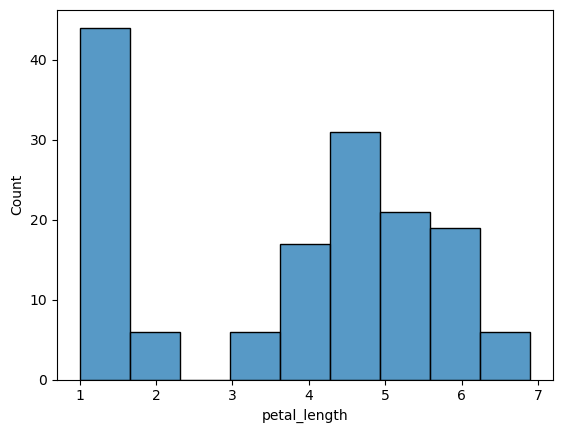

In [6]:
sns.histplot(iris,x = 'petal_length')
plt.show()

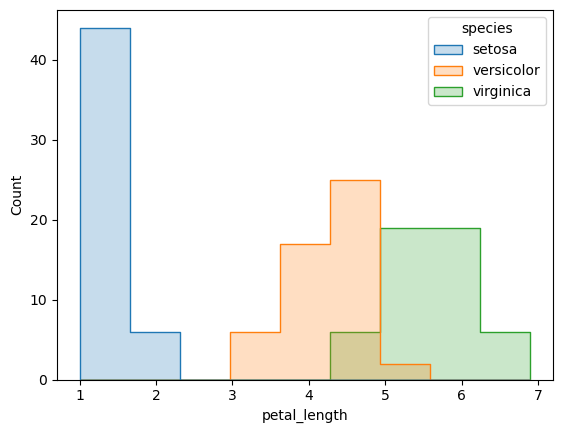

In [7]:
## pas besoin d'une boucle for pour ajouter des couches de couleurs
sns.histplot(data=iris, x= 'petal_length', hue = 'species', element='step') 
# hue == teinte == couleur
plt.show()

[]


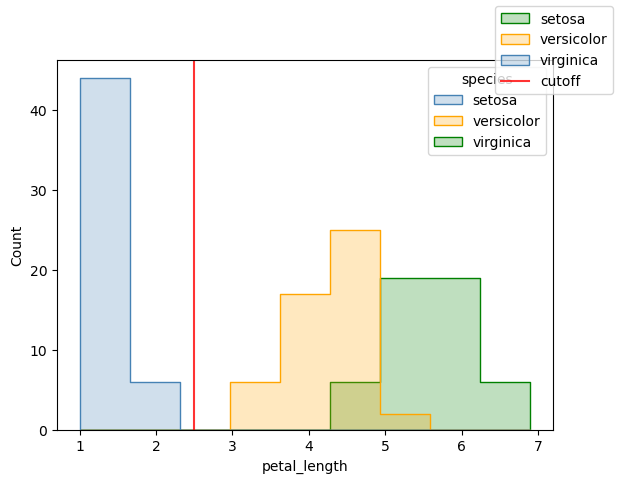

In [71]:
## pas besoin d'une boucle for pour ajouter des couches de couleurs
fig,ax = plt.subplots()

palette = {"setosa":"steelblue","versicolor":"orange","virginica":"green"}

iris["species_order"] = iris["species"].map({"setosa":0,"versicolor":1,"virginica":2})


g = sns.histplot(data=iris.sort_values(by="species_order",ascending=True), x= 'petal_length', hue = 'species', element='step',palette=palette,ax=ax)

L = g.get_lines()
print([el for el in L])
line = ax.axvline(x=2.5, ymin=0,ymax=45,label="cutoff", c="red",alpha=0.8)

plt.figlegend(labels=["setosa","versicolor","virginica","cutoff"])


plt.show()

In [46]:
g.legend_.get_lines()

[]

### pie-chart
- n'existe pas dans seaborn (pas souvent utilisé pour des stats, mais bien en business)

## extension de graphiques
### kde-plot
- kernel density estimator = histogramme lissé

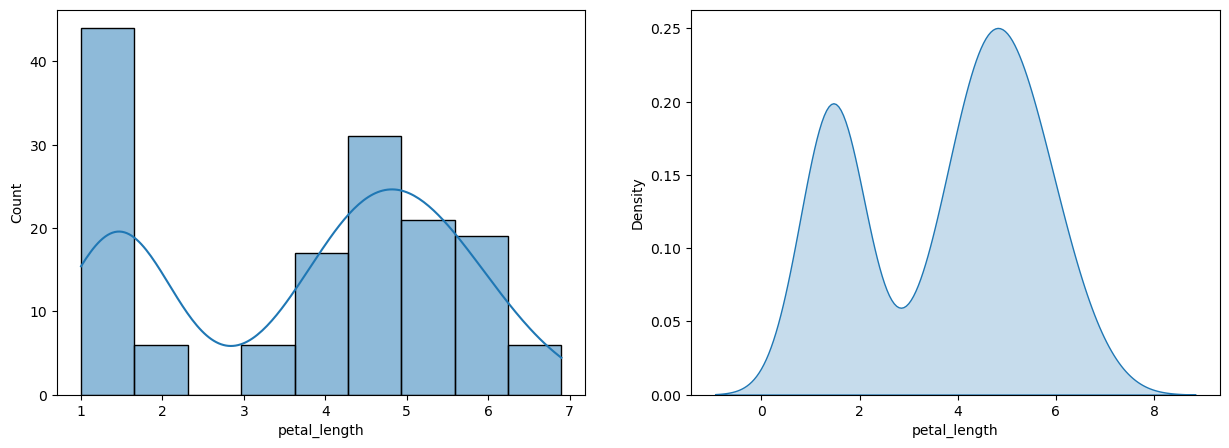

In [8]:
### intégration avec toutes les fonctionnalités de matplotlib

plt.figure(figsize=(15,5))
plt.subplot(1,2,1)

sns.histplot(data=iris,x='petal_length', kde=True) ## plus de paramètres statistiques que matplotlib 

plt.subplot(1,2,2)
sns.kdeplot(data=iris, x='petal_length', fill=True) ## kernel density estimator = histogramme lissé

plt.show()

### boxplot
- boite de dispersion
- boite à moustache
- (aussi disponible dans matplotlib) 

- utilisation pour usage similaire à un histogram (mais plus simplifié)

- la structure du graphique :
    - (valeurs extrêmes s'ils existent) ->"Min"- > Q1 -> Mediane -> Q3 -> "Max" -> (valeurs extrêmes s'ils existent)
    - Q1 = la médiane entre la médiane (Q2) et le minimum
    - Q3 = la médiane entre la médiane et le maximum
    - "Min","Max" = les moustaches avec une distance maximale qui dépends de la distance entre Q1 et Q3 (pour plus de détail voir cours de statistiques)


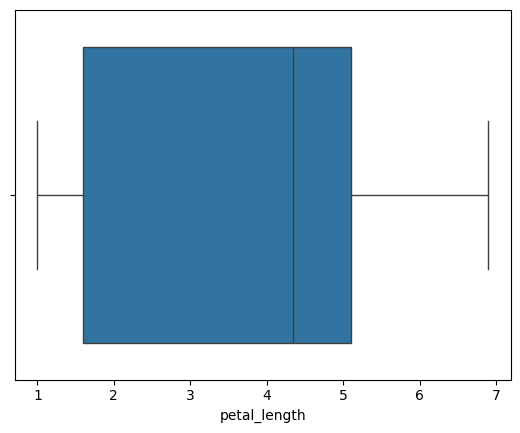

In [9]:
sns.boxplot(data=iris,x='petal_length') ## boite à moustache: affiche la médiane ainsi que Q1 et Q3 (voir statistiques)
plt.show()

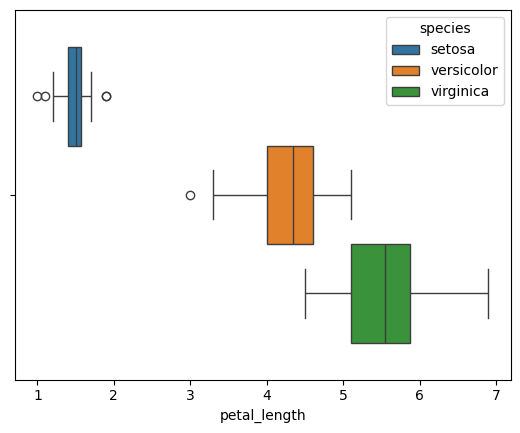

In [10]:
sns.boxplot(data=iris,x='petal_length',hue="species",) ## boite à moustache: affiche la médiane ainsi que Q1 et Q3 (voir statistiques)
plt.show()

### violin plot
- graphique en violon
- = combinaison entre :
    - le "boxplot" : la barre au milieu
    - "kde" (=avec rotation 90 degrées)

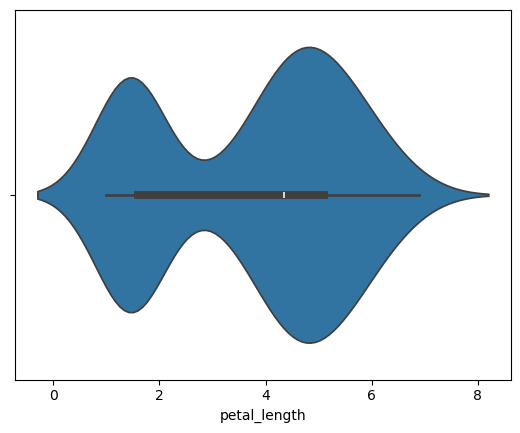

In [11]:
### combinaison d'un 'boxplot' et kde/histogram (=rotation 90 degrées)
sns.violinplot(data=iris,x='petal_length',) 
plt.show()

### jointplot
- combinaison de graphiques univarié (histogram simple) avec bivarié (nuage de points)

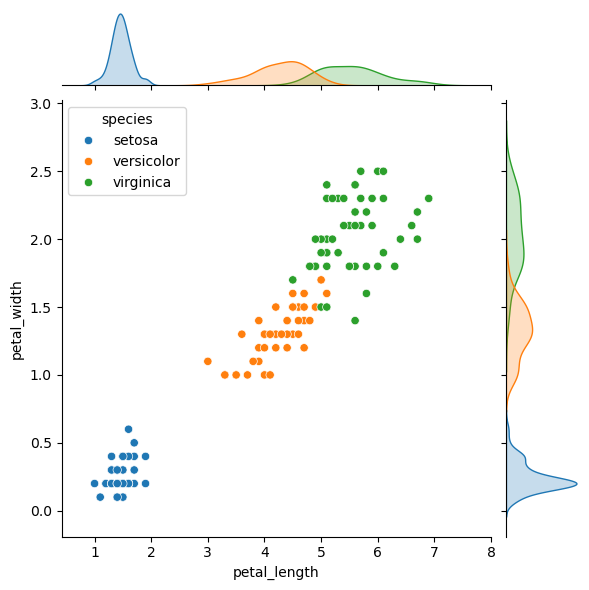

In [12]:
sns.jointplot(data=iris,x='petal_length',y="petal_width", kind='scatter',hue="species")
plt.show()

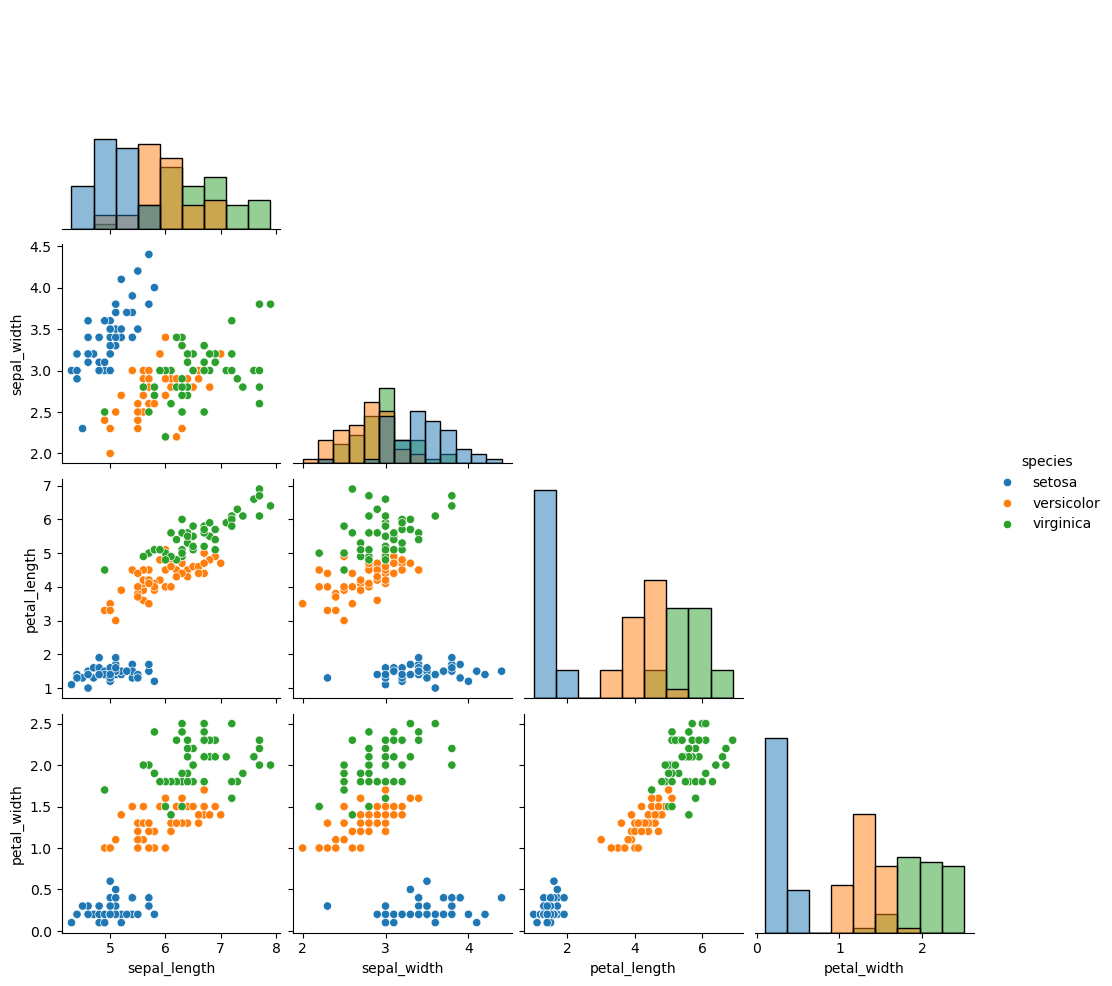

In [13]:
sns.pairplot(data=iris
             ,hue="species", diag_kind="hist"
             , corner=True)
plt.show()

### bien plus ...


In [14]:
sns.heatmap
sns.boxenplot
sns.swarmplot

...

Ellipsis